In [3]:
# installer les librairies manquantes
!pip install yfinance statsmodels pmdarima

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 711.9/711.9 kB 5.9 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.3 MB 8.0 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.3 MB 7.8 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 6.2 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 6.8 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.3 MB 6.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 6.7 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 6.7 MB/s eta 0:00:01
   -------------------------------------- - 10.7/11.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 6.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -----------------

In [5]:
import os                        # gestion des dossiers
import json                      # sauvegarde du split
import warnings                  # masquer les warnings
import numpy as np               # calcul numérique
import pandas as pd              # tableaux / séries
import matplotlib.pyplot as plt  # graphiques
import yfinance as yf            # données Yahoo Finance

# graphiques dans le notebook
%matplotlib inline

warnings.filterwarnings("ignore")
np.random.seed(42)               # reproductibilité

for d in ["data", "results/figures", "results/tables"]:
    os.makedirs(d, exist_ok=True)   # créer les dossiers s'ils n'existent pas

print(os.getcwd())               # dossier de travail

C:\Users\HP\Documents\IISExpress\BTC_ETH_TimeSeries


In [8]:
DATA = "data/btc_eth.csv"        # fichier commun à l'équipe

if not os.path.exists(DATA):     # télécharger une seule fois
    raw = yf.download(["BTC-USD", "ETH-USD"], start="2018-01-01", end="2026-10-01",
                      auto_adjust=False, progress=False)   # end exclu -> 30/09/2026
    df = pd.DataFrame({
        "btc_close": raw["Close"]["BTC-USD"],     # prix clôture BTC
        "eth_close": raw["Close"]["ETH-USD"],     # prix clôture ETH
        "btc_volume": raw["Volume"]["BTC-USD"],   # volume BTC
        "eth_volume": raw["Volume"]["ETH-USD"],   # volume ETH
    })
    df.index.name = "date"
    df.to_csv(DATA)              # sauvegarde du csv

df = pd.read_csv(DATA, parse_dates=["date"], index_col="date").sort_index()  # lecture, date en index

print("Période :", df.index.min().date(), "->", df.index.max().date())  # vérif période
print("Nb lignes :", len(df))    # vérif taille
df.head(5)                        # aperçu

Période : 2018-01-01 -> 2026-09-30
Nb lignes : 3195


,btc_close,eth_close,btc_volume,eth_volume
date,,,,
2018-01-01,13657.200195,772.640991,10291200000,2595760128
2018-01-02,14982.099609,884.443970,16846600192,5783349760
2018-01-03,15201.000000,962.719971,16871900160,5093159936
2018-01-04,15599.200195,980.921997,21783199744,6502859776
2018-01-05,17429.500000,997.719971,23840899072,6683149824


In [9]:
# vérification des jours manquants
jours = pd.date_range(df.index.min(), df.index.max(), freq="D")   # tous les jours attendus
manquants = jours.difference(df.index)                             # jours absents
print("Jours manquants :", len(manquants))

# doublons de date
print("Doublons :", df.index.duplicated().sum())

# valeurs vides
print("Valeurs NaN :")
print(df.isna().sum())

# on force une ligne par jour
df = df[~df.index.duplicated(keep="first")]    # supprimer doublons
df = df.reindex(jours)                         # ajouter les jours manquants (NaN)
df.index.name = "date"

# remplir avec le dernier prix connu
df = df.ffill()

print("Après nettoyage :", len(df), "lignes,", df.isna().sum().sum(), "NaN")

Jours manquants : 0
Doublons : 0
Valeurs NaN :
btc_close     0
eth_close     0
btc_volume    0
eth_volume    0
dtype: int64
Après nettoyage : 3195 lignes, 0 NaN


In [10]:
for a in ["btc", "eth"]:
    df[f"{a}_logp"] = np.log(df[f"{a}_close"])                    # log-prix
    df[f"{a}_ret"] = df[f"{a}_logp"].diff()                         # log-rendement
    df[f"{a}_ma50"] = df[f"{a}_close"].rolling(50).mean()           # moyenne mobile 50 j
    df[f"{a}_ma200"] = df[f"{a}_close"].rolling(200).mean()         # moyenne mobile 200 j
    df[f"{a}_vol30"] = df[f"{a}_ret"].rolling(30).std() * np.sqrt(365)  # volatilité 30 j annualisée

df.to_csv("data/btc_eth_processed.csv")    # sauvegarde des données traitées

# split chronologique 90 / 10
n = len(df)
cut = df.index[int(n * 0.9)]               # 1er jour du test
split = {
    "train_end": str((cut - pd.Timedelta(days=1)).date()),
    "test_start": str(cut.date()),
    "test_end": str(df.index[-1].date()),
    "n_train": int((df.index < cut).sum()),
    "n_test": int((df.index >= cut).sum()),
}
with open("data/split.json", "w") as f:
    json.dump(split, f, indent=2)          # même split pour toute l'équipe

print(split)
df[["btc_close", "btc_logp", "btc_ret", "btc_vol30"]].tail()

{'train_end': '2025-11-14', 'test_start': '2025-11-15', 'test_end': '2026-09-30', 'n_train': 2875, 'n_test': 320}


,btc_close,btc_logp,btc_ret,btc_vol30
date,,,,
2026-09-26,84406.453125,11.343399,0.004411,0.428915
2026-09-27,84458.085938,11.344011,0.000612,0.412754
2026-09-28,83502.609375,11.332633,-0.011378,0.415532
2026-09-29,83622.429688,11.334067,0.001434,0.414107
2026-09-30,83553.851562,11.333247,-0.000820,0.413013


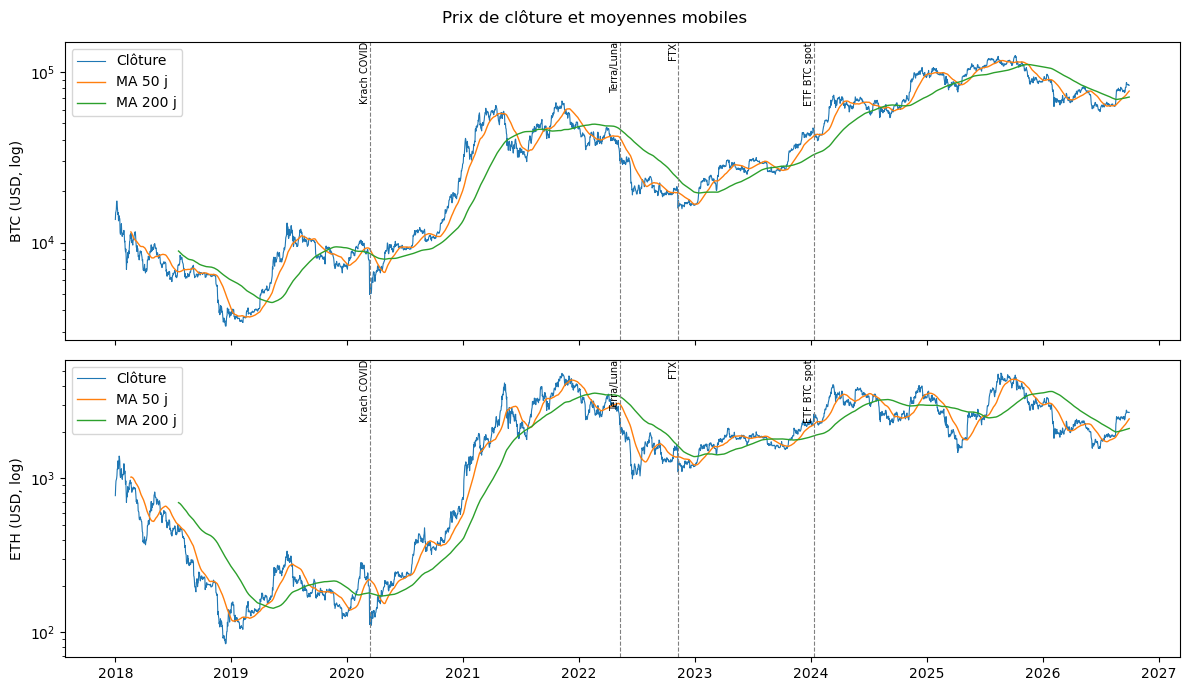

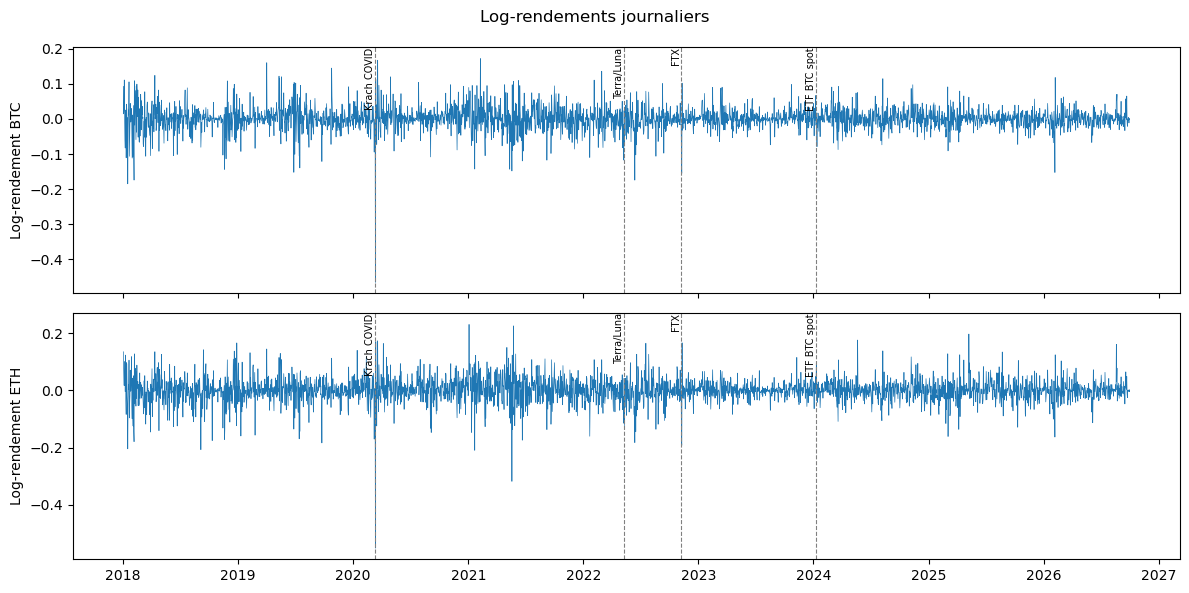

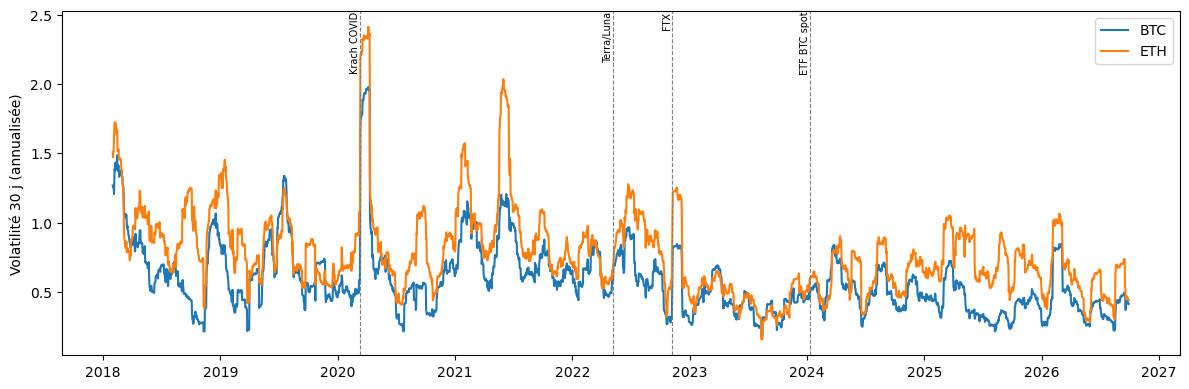

In [11]:
# événements importants à marquer sur les graphes
events = {"2020-03-12": "Krach COVID", "2022-05-09": "Terra/Luna",
          "2022-11-08": "FTX", "2024-01-10": "ETF BTC spot"}

def marquer(ax):
    for d, lab in events.items():
        ax.axvline(pd.Timestamp(d), color="grey", ls="--", lw=0.8)        # ligne verticale
        ax.text(pd.Timestamp(d), ax.get_ylim()[1], lab, rotation=90,
                va="top", ha="right", fontsize=7)                          # nom de l'événement

# 1) prix + moyennes mobiles (échelle log)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, a in zip(axes, ["btc", "eth"]):
    ax.plot(df[f"{a}_close"], lw=0.8, label="Clôture")
    ax.plot(df[f"{a}_ma50"], lw=1, label="MA 50 j")
    ax.plot(df[f"{a}_ma200"], lw=1, label="MA 200 j")
    ax.set_yscale("log")                                                   # échelle log
    ax.set_ylabel(f"{a.upper()} (USD, log)")
    ax.legend(loc="upper left")
    marquer(ax)
fig.suptitle("Prix de clôture et moyennes mobiles")
fig.tight_layout()
fig.savefig("results/figures/01_prix_ma.png", dpi=150)
plt.show()

# 2) log-rendements
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, a in zip(axes, ["btc", "eth"]):
    ax.plot(df[f"{a}_ret"], lw=0.5)
    ax.set_ylabel(f"Log-rendement {a.upper()}")
    marquer(ax)
fig.suptitle("Log-rendements journaliers")
fig.tight_layout()
fig.savefig("results/figures/01_rendements.png", dpi=150)
plt.show()

# 3) volatilité réalisée 30 j
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["btc_vol30"], label="BTC")
ax.plot(df["eth_vol30"], label="ETH")
ax.set_ylabel("Volatilité 30 j (annualisée)")
ax.legend()
marquer(ax)
fig.tight_layout()
fig.savefig("results/figures/01_volatilite_30j.png", dpi=150)
plt.show()

In [13]:
from scipy import stats

lignes = []
for a in ["btc", "eth"]:
    r = df[f"{a}_ret"].dropna()                # rendements sans le 1er NaN valeurs vides
    jb = stats.jarque_bera(r)                  # test de normalité 
    lignes.append({
        "actif": a.upper(),
        "n": len(r),
        "moyenne": r.mean(),
        "ecart_type": r.std(),
        "variance": r.var(),
        "min": r.min(),
        "max": r.max(),
        "skewness": stats.skew(r),             # asymétrie
        "kurtosis": stats.kurtosis(r),         # excès de kurtosis (normale = 0)
        "JB_stat": jb.statistic,
        "JB_pvalue": jb.pvalue,
    })

desc = pd.DataFrame(lignes).set_index("actif").round(4)
desc.to_csv("results/tables/01_stats_descriptives.csv")    # pour le rapport + Personne 3 (LLM)

print("Corrélation rendements BTC/ETH :", round(df["btc_ret"].corr(df["eth_ret"]), 3))
desc.T

Corrélation rendements BTC/ETH : 0.829


actif,BTC,ETH
n,3194.0000,3194.0000
moyenne,0.0006,0.0004
ecart_type,0.0335,0.0441
variance,0.0011,0.0019
min,-0.4647,-0.5507
max,0.1718,0.2307
skewness,-0.9438,-0.8263
kurtosis,14.8448,11.0966
JB_stat,29801.4256,16750.5062
JB_pvalue,0.0000,0.0000


actif
BTC    60
ETH    40
dtype: int64


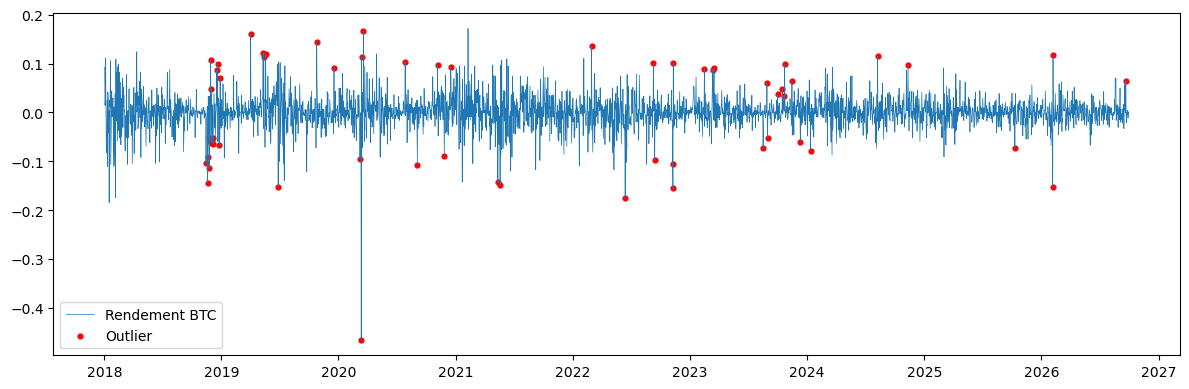

,actif,date,rendement
74,ETH,2020-03-12,-0.5507
24,BTC,2020-03-12,-0.4647
81,ETH,2021-05-19,-0.3175
80,ETH,2021-01-21,-0.2090
60,ETH,2018-09-05,-0.2069
84,ETH,2022-11-09,-0.1918
71,ETH,2019-09-24,-0.1833
61,ETH,2018-10-11,-0.1751
35,BTC,2022-06-13,-0.1741
63,ETH,2018-11-19,-0.1714


In [14]:
lignes = []
for a in ["btc", "eth"]:
    r = df[f"{a}_ret"]
    q1 = r.rolling(90, min_periods=60).quantile(0.25)    # 1er quartile sur 90 j
    q3 = r.rolling(90, min_periods=60).quantile(0.75)    # 3e quartile sur 90 j
    iqr = q3 - q1
    outlier = (r < q1 - 3 * iqr) | (r > q3 + 3 * iqr)   # hors des bornes = outlier
    df[f"{a}_outlier"] = outlier.astype(int)             # indicatrice 0/1

    for d in r[outlier].index:
        lignes.append({"actif": a.upper(), "date": d.date(), "rendement": round(r[d], 4)})

outliers = pd.DataFrame(lignes)
outliers.to_csv("results/tables/01_outliers.csv", index=False)
print(outliers.groupby("actif").size())                  # nombre par actif

# graphe : rendements BTC avec outliers en rouge
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["btc_ret"], lw=0.5, label="Rendement BTC")
o = df[df["btc_outlier"] == 1]
ax.scatter(o.index, o["btc_ret"], color="red", s=12, label="Outlier")
ax.legend()
fig.tight_layout()
fig.savefig("results/figures/01_outliers_btc.png", dpi=150)
plt.show()

outliers.sort_values("rendement").head(10)               # les 10 pires chocs

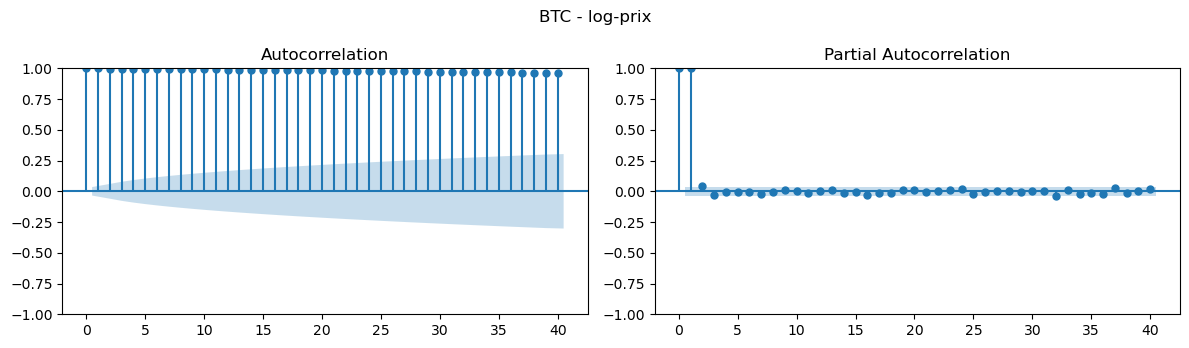

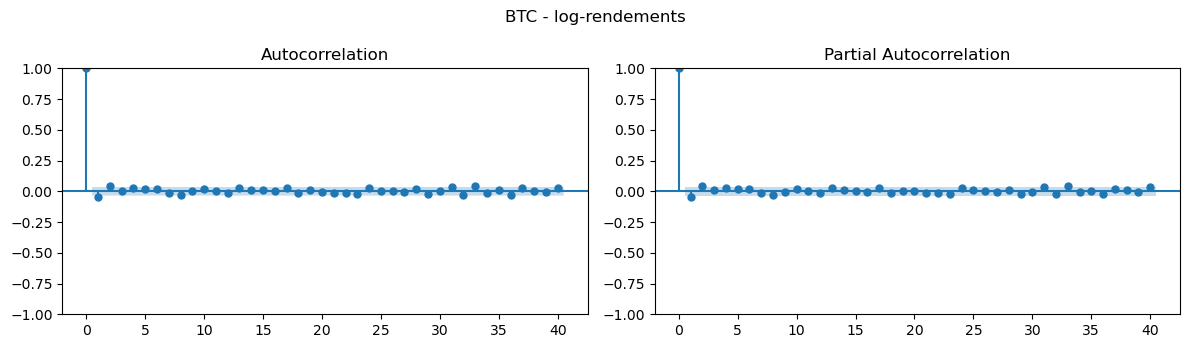

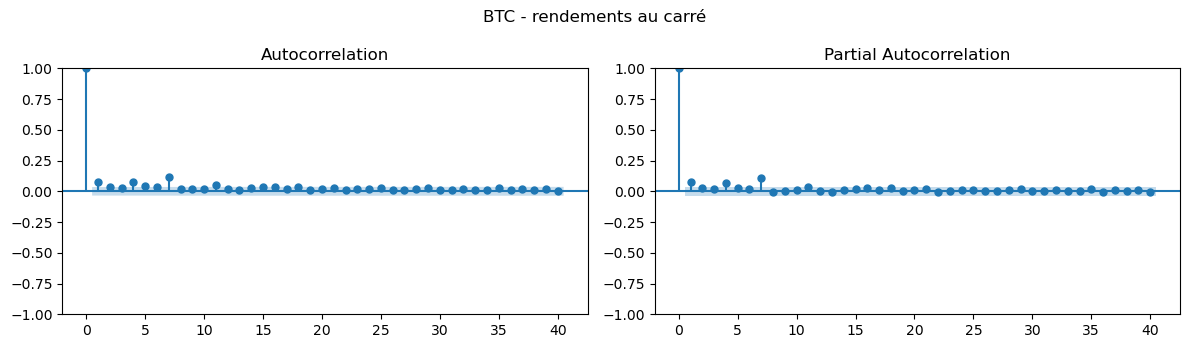

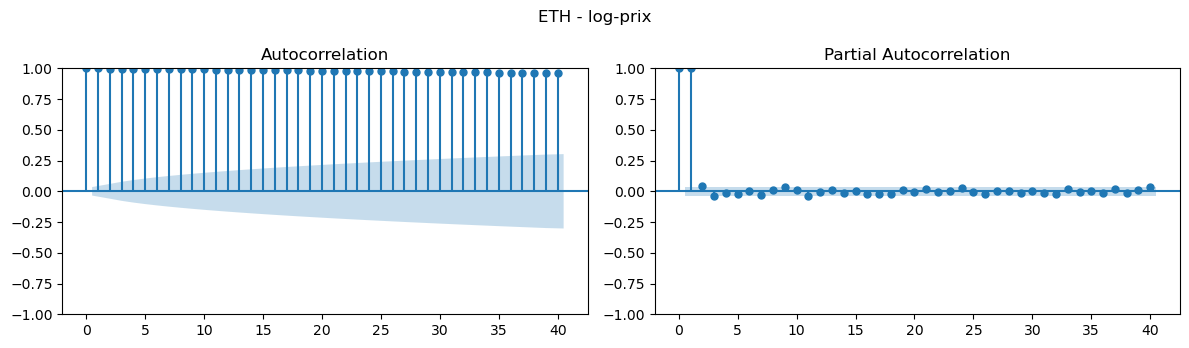

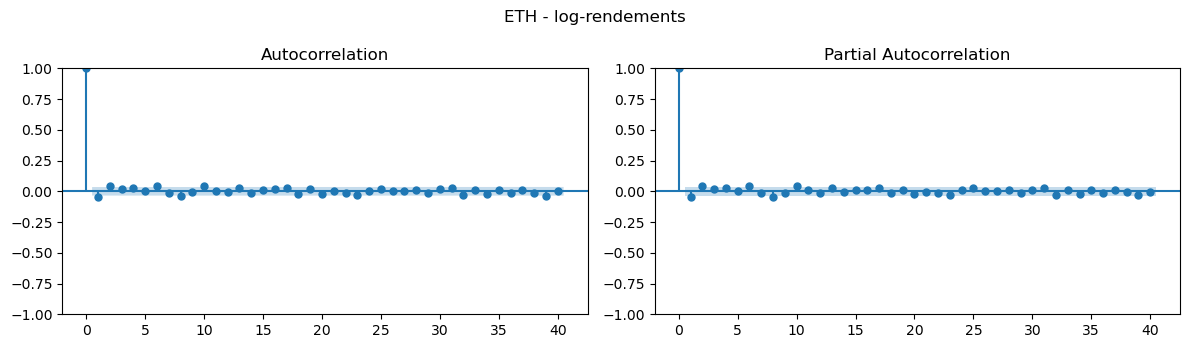

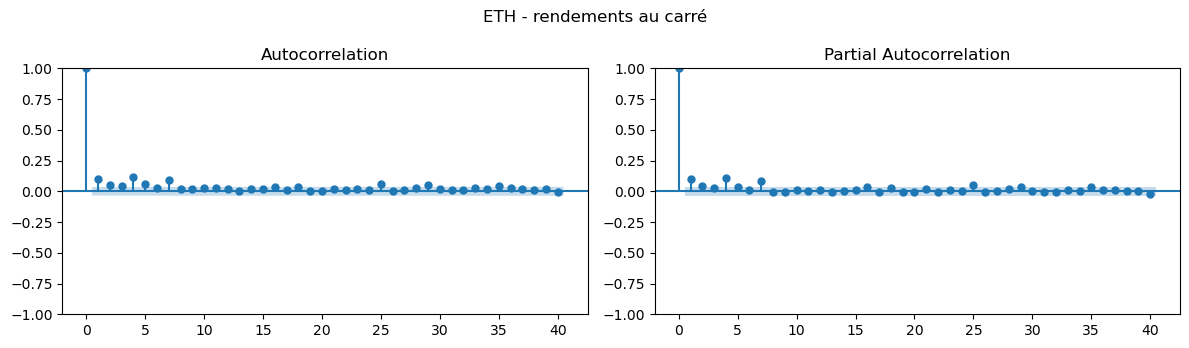

In [16]:
# ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def acf_pacf(serie, titre, fichier, lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_acf(serie.dropna(), lags=lags, ax=axes[0])                    # autocorrélation
    plot_pacf(serie.dropna(), lags=lags, ax=axes[1], method="ywm")     # autocorrélation partielle
    fig.suptitle(titre)
    fig.tight_layout()
    fig.savefig(f"results/figures/{fichier}", dpi=150)
    plt.show()

for a in ["btc", "eth"]:
    acf_pacf(df[f"{a}_logp"], f"{a.upper()} - log-prix", f"01_acf_logprix_{a}.png")
    acf_pacf(df[f"{a}_ret"], f"{a.upper()} - log-rendements", f"01_acf_rendements_{a}.png")
    acf_pacf(df[f"{a}_ret"] ** 2, f"{a.upper()} - rendements au carré", f"01_acf_rendements2_{a}.png")

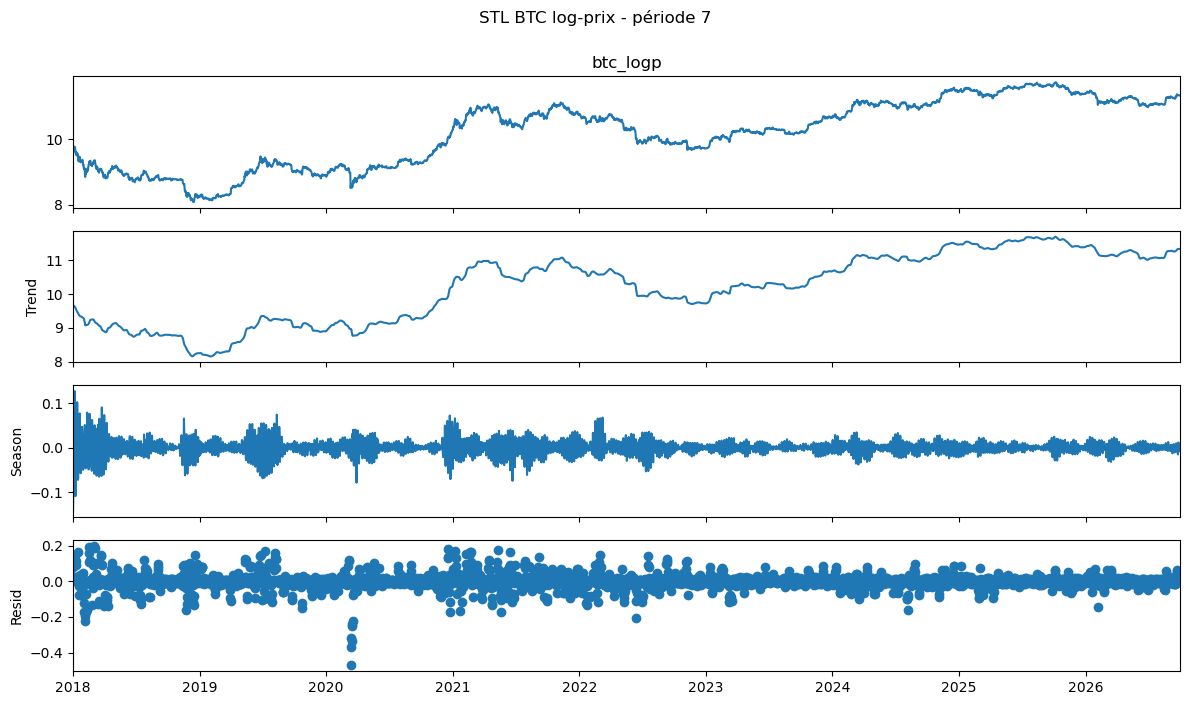

BTC période 7 : force saisonnalité = 0.000


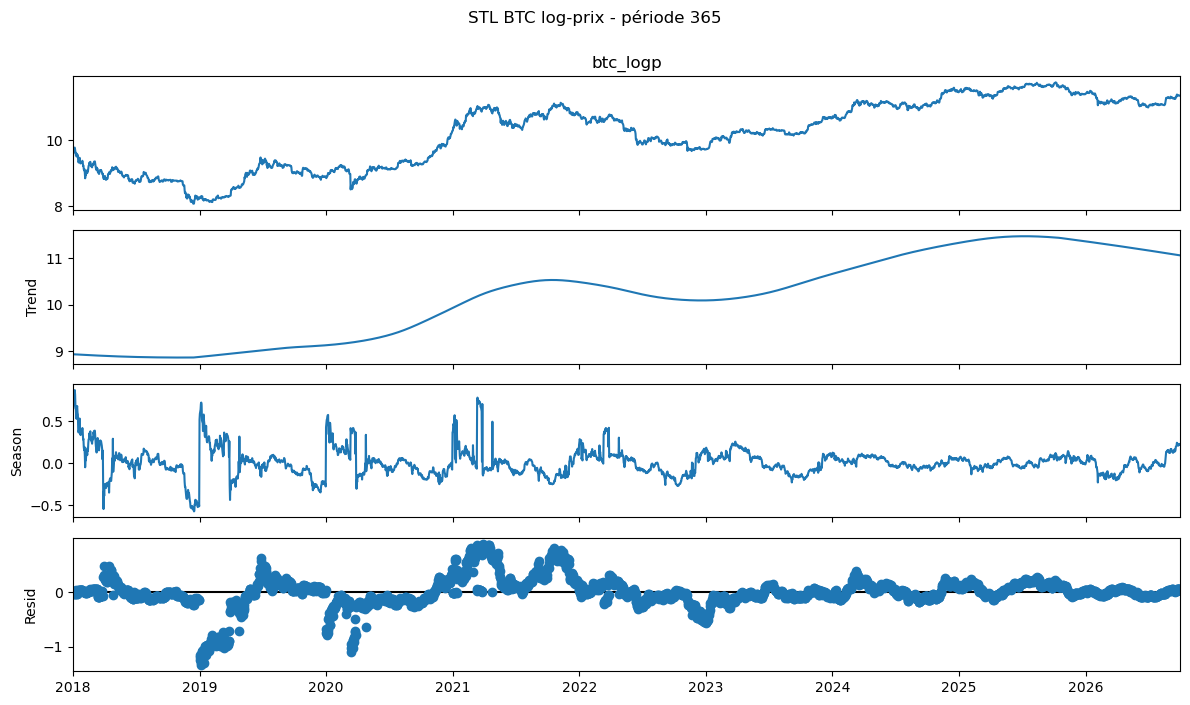

BTC période 365 : force saisonnalité = 0.000


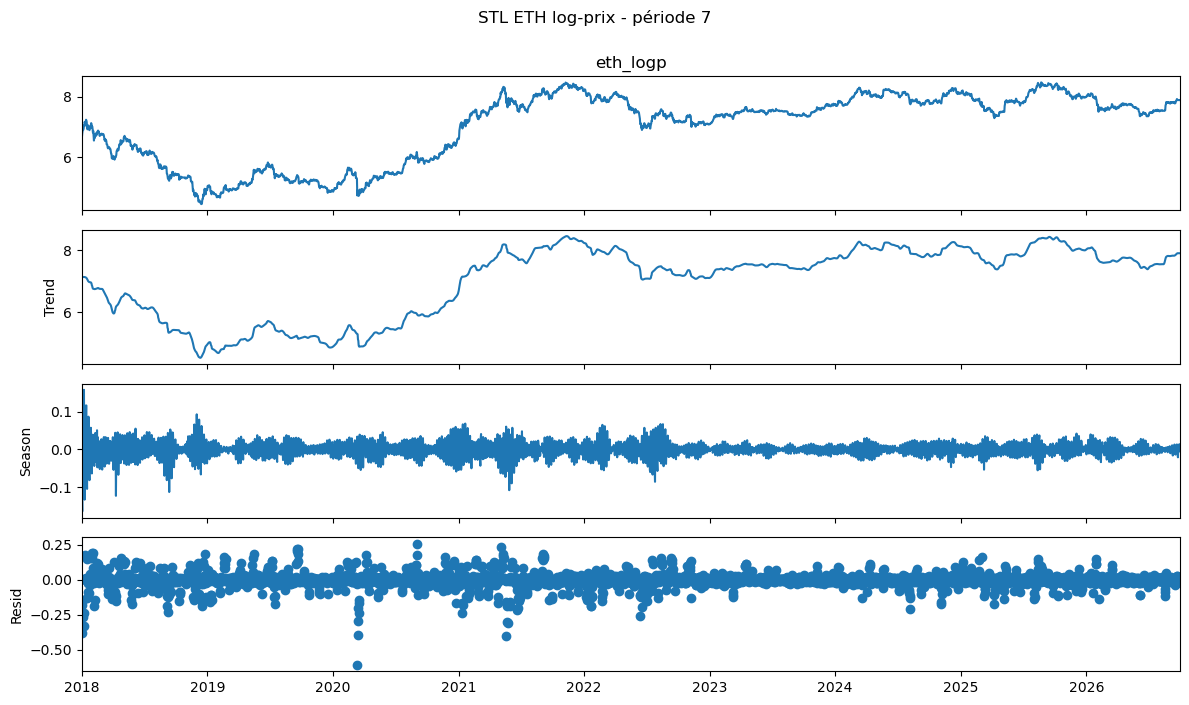

ETH période 7 : force saisonnalité = 0.007


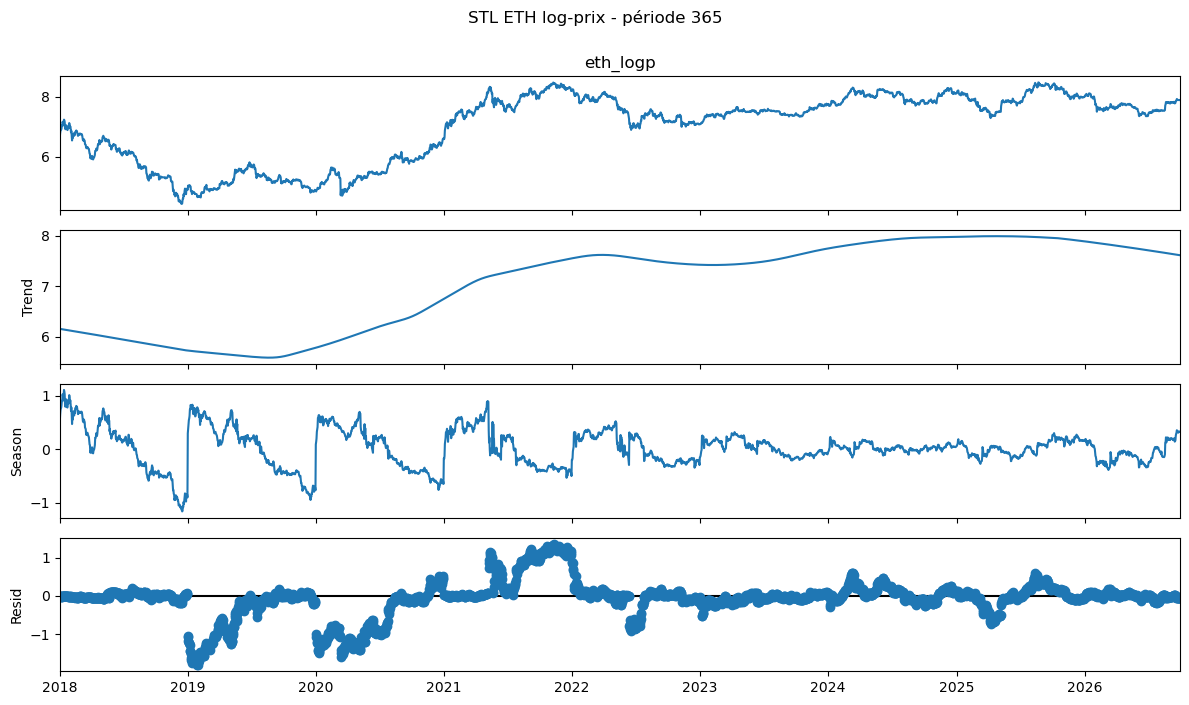

ETH période 365 : force saisonnalité = 0.000


In [21]:
# Décomposition STL
from statsmodels.tsa.seasonal import STL

for a in ["btc", "eth"]:
    for periode in [7, 365]:                               # saisonnalité hebdo puis annuelle
        res = STL(df[f"{a}_logp"], period=periode, robust=True).fit()

        fig = res.plot()
        fig.set_size_inches(12, 7)
        fig.suptitle(f"STL {a.upper()} log-prix - période {periode}", y=1.0)
        fig.tight_layout()
        fig.savefig(f"results/figures/01_stl_{a}_{periode}.png", dpi=150)
        plt.show()

        # force de la saisonnalité : proche de 0 = pas de saisonnalité
        force = max(0, 1 - np.var(res.resid) / np.var(res.seasonal + res.resid))
        print(f"{a.upper()} période {periode} : force saisonnalité = {force:.3f}")

In [22]:
# ADF et KPSS
from statsmodels.tsa.stattools import adfuller, kpss

lignes = []
for a in ["btc", "eth"]:
    for var, nom in [("logp", "log-prix"), ("ret", "log-rendement")]:
        x = df[f"{a}_{var}"].dropna()
        reg = "ct" if var == "logp" else "c"          # constante + tendance pour les prix, constante seule pour les rendements

        adf = adfuller(x, regression=reg, autolag="AIC")   # H0 : racine unitaire
        kp = kpss(x, regression=reg, nlags="auto")         # H0 : stationnaire

        stationnaire = (adf[1] < 0.05) and (kp[1] > 0.05)  # les deux tests doivent être d'accord
        lignes.append({
            "actif": a.upper(),
            "serie": nom,
            "ADF_stat": round(adf[0], 3),
            "ADF_p": round(adf[1], 4),
            "KPSS_stat": round(kp[0], 3),
            "KPSS_p": round(kp[1], 4),
            "conclusion": "stationnaire" if stationnaire else "non stationnaire",
        })

statio = pd.DataFrame(lignes)
statio.to_csv("results/tables/01_stationnarite.csv", index=False)
statio

C:\Users\HP\AppData\Local\Temp\ipykernel_16500\1906600564.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kp = kpss(x, regression=reg, nlags="auto")         # H0 : stationnaire
C:\Users\HP\AppData\Local\Temp\ipykernel_16500\1906600564.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(x, regression=reg, nlags="auto")         # H0 : stationnaire
C:\Users\HP\AppData\Local\Temp\ipykernel_16500\1906600564.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kp = kpss(x, regression=reg, nlags="auto")         # H0 : stationnaire
C:\Users\HP\AppData\Local\Temp\ipykernel_16500\1906600564.py:11: InterpolationWarning: T

,actif,serie,ADF_stat,ADF_p,KPSS_stat,KPSS_p,conclusion
0,BTC,log-prix,-2.458,0.3494,0.386,0.01,non stationnaire
1,BTC,log-rendement,-19.833,0.0000,0.108,0.10,stationnaire
2,ETH,log-prix,-2.344,0.4096,0.760,0.01,non stationnaire
3,ETH,log-rendement,-17.178,0.0000,0.125,0.10,stationnaire
